# Lab 5: TCP Calibration (worked solutions)

Companion to `TCPCalibrationTemplate.ipynb` and `pdfs/TCP_Calibration.pdf`.
Layout: **Task → Solution → How it works → Example / check**. This lab is fully offline (measurement data is given), it
never touches the robot.

**The idea in one paragraph.** The URDF ends at the flange. A tool (gripper, pen, suction nozzle) sits some distance
beyond it, and the *tool centre point* (TCP) is the point that must land on the target. The unknown is the rigid
transform ${}^F T_T$ from flange frame to TCP frame. If for each of several robot poses $i$ we know the flange pose
${}^B T_{F,i}$ (forward kinematics) **and** the measured TCP pose ${}^B T_{TCP,i}$, then each pose gives one estimate
$$ {}^F T_{T,i} = \big({}^B T_{F,i}\big)^{-1}\,{}^B T_{TCP,i}, $$
and averaging the estimates (translation: mean; rotation: SVD mean) gives one calibrated offset. The **residuals** tell
how consistent the data are.

**Data note.** The measurements are the ones stored in the controller code (`fk_tool_calib.py`). With the URDF
that is used here, this notebook reproduces the tool offset and the base correction that the controller's launch file
contains **to six digits** (Tasks 14 and 15). That also tells us that the fallback URDF (`labpaths`) is the same
kinematic chain that was used to produce the launch-file values.

## Setup

In [1]:
%matplotlib widget
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3
import labpaths          # solutions/labpaths.py: repo root on sys.path + URDF location
from helperFunctions import (
    rpy_to_rot, rpy_to_transform, rot_to_vec, transform_to_pipi,
)

np.set_printoptions(precision=6, suppress=True)

---
## Task 1: Import the URDF

In [2]:
mycobot_urdf_path = labpaths.urdf_path()     # template: os.path.join(os.getcwd(), 'mycobot_280_gazebo.urdf')
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

NOTE: mycobot_280_gazebo.urdf not found in the repo root.
      Using the fallback /home/mano-ub22/TUD/cobots/ros2_ws/src/mycobot_description/urdf/mycobot_280_pi/mycobot_280_pi.urdf
      (same kinematic chain as far as checked, see solutions/labpaths.py)
ERobot: firefighter, 6 joints (RRRRRR), geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ g_base         │       │ BASE   │ SE3()                                               │
│    1 │ joint1         │       │ g_base │ SE3()                                               │
│    2 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    3 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    

/tmp/ipykernel_62102/3513415727.py:2: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


**How it works:** as in Labs 3 and 4: `Robot.URDF` builds the model, `mycobot.links` lists the links.

---
## Task 2: The relevant frames

In [3]:
base_link = 'g_base'
flange_link = 'joint6_flange'

# Verify FK at home configuration
q_home = np.zeros(mycobot.n)
T_home = mycobot.fkine(q_home, end=flange_link)
print('Flange pose at home:\n', T_home)

Flange pose at home:
    0        -3.673e-06  1         0.0456    
  -1         3.673e-06  1.349e-11 -0.06362   
  -3.673e-06 -1        -3.673e-06  0.4181    
   0         0         0         1         



**How it works**
- **Base frame** `g_base`: fixed to the robot's mounting surface. **Flange frame** `joint6_flange`: attached to the last
  link, it belongs to the robot and comes from FK. **TCP frame**: attached to whatever is mounted on the flange; it is
  what we calibrate.
- `np.zeros(mycobot.n)`: an all-zero joint vector (the arm straight up). The printed pose: flange 0.0456 m to the
  side of and 0.418 m above the base.
- After calibration the offset is passed to the controller (`ik_tool_xyz`, `ik_tool_rpy`), so Cartesian targets refer to
  the TCP instead of the flange (Task 17).

---
## Task 3: Load the calibration samples

In [4]:
# Actual calibration samples from fk_tool_calib.py
# Format: (joint_angles_deg, tcp_xyz_mm, tcp_rpy_deg)
samples = [
    ([-0.87, -2.02, -89.91, 89.38, 1.05, 0.7],
     [147.7, -64.8, 319.4],
     [-92.54, 0.74, -89.85]),

    ([-0.52, -0.87, -0.61, -0.08, 0.96, 0.61],
     [51.1, -63.1, 419.5],
     [-91.58, 0.64, -89.66]),

    ([9.49, 20.56, 29.61, 40.86, 49.3, 59.41],
     [-180.7, -59.4, 332.6],
     [-44.61, -23.67, -11.74]),

    ([59.23, 51.15, 39.9, 31.02, 20.83, 10.63],
     [-96.6, -254.5, 203.1],
     [30.49, -23.21, -32.58]),

    ([-59.15, -50.71, -40.34, 39.28, 49.3, 59.41],
     [107.9, -236.9, 230.6],
     [158.88, 56.69, 158.02]),
]

print(f'Number of calibration samples: {len(samples)}')

Number of calibration samples: 5


**How it works**
- `samples` is a **list of tuples**, each tuple = (joint angles, TCP position, TCP orientation), each of those a
  list of numbers. Access: `samples[0]` is the first tuple, `samples[0][1]` its TCP position.
- Units are the robot API's: degrees and millimetres.
- The joint angles were read from the encoders; position and RPY come from the API call `get_coords`, i.e. from the
  robot's **own internal kinematics**. That matters for interpretation (Task 13): the offset we estimate will mostly
  absorb differences between that internal model and the URDF, so it is small (about 2 mm), unlike a real tool.
- The poses differ a lot in position and orientation (e.g. sample 5 has roll = 159°), which is what makes a
  calibration well-conditioned.

---
## Task 4: Convert one sample to SI units

In [5]:
angles_deg, tcp_xyz_mm, tcp_rpy_deg = samples[0]

q_rad = np.radians(angles_deg)              # degrees -> radians
tcp_xyz_m = np.array(tcp_xyz_mm) / 1000.0   # millimetres -> metres
tcp_rpy_rad = np.radians(tcp_rpy_deg)       # degrees -> radians

print('q (rad):', q_rad)
print('TCP xyz (m):', tcp_xyz_m)
print('TCP rpy (rad):', tcp_rpy_rad)

q (rad): [-0.015184 -0.035256 -1.569226  1.559975  0.018326  0.012217]
TCP xyz (m): [ 0.1477 -0.0648  0.3194]
TCP rpy (rad): [-1.615128  0.012915 -1.568178]


**How it works**
- `angles_deg, tcp_xyz_mm, tcp_rpy_deg = samples[0]`: **tuple unpacking**, the three parts go into three names.
- `np.radians(list)` converts a whole list at once and returns an array (`np.deg2rad` is the same function).
- `np.array(tcp_xyz_mm) / 1000.0`: a plain Python list cannot be divided (`[1, 2] / 1000` is a `TypeError`), but a NumPy
  array is divided **element-wise**. Hence the `np.array(...)` first.

---
## Task 5: Flange-to-TCP transform for one sample
$$ {}^F T_{T,i} = \big({}^B T_{F,i}\big)^{-1}\;{}^B T_{TCP,i} $$

In [6]:
# Step 1: FK to get flange pose in base frame
T_base_flange = mycobot.fkine(q_rad, end=flange_link).A

# Step 2: Assemble measured TCP pose using codebase RPY convention
T_base_tcp = rpy_to_transform(tcp_xyz_m, tcp_rpy_rad)

# Step 3: Per-sample flange-to-TCP transform
T_flange_tcp = np.linalg.inv(T_base_flange) @ T_base_tcp

print('Flange pose (base frame):\n', T_base_flange)
print('Measured TCP pose (base frame):\n', T_base_tcp)
print('Flange-to-TCP transform:\n', T_flange_tcp)
print('TCP offset (mm):', T_flange_tcp[:3, 3] * 1000.0)

Flange pose (base frame):
 [[ 0.00258  -0.044525  0.999005  0.14767 ]
 [-0.999912  0.012896  0.003157 -0.065035]
 [-0.013024 -0.998925 -0.044487  0.316737]
 [ 0.        0.        0.        1.      ]]
Measured TCP pose (base frame):
 [[ 0.002618 -0.04435   0.999013  0.1477  ]
 [-0.999913  0.012786  0.003188 -0.0648  ]
 [-0.012915 -0.998934 -0.044313  0.3194  ]
 [ 0.        0.        0.        1.      ]]
Flange-to-TCP transform:
 [[ 1.        0.00011  -0.000033 -0.00027 ]
 [-0.00011   1.       -0.000174 -0.002658]
 [ 0.000033  0.000174  1.       -0.000087]
 [ 0.        0.        0.        1.      ]]
TCP offset (mm): [-0.269679 -2.658363 -0.087355]


**How it works**
- **Step 1:** `fkine(q, end=...).A` = 4×4 pose of the flange in the base frame, from the joint angles.
- **Step 2:** `rpy_to_transform(xyz, rpy)` (helperFunctions) builds a 4×4 pose from position and roll-pitch-yaw,
  with $R = R_z(\text{yaw})R_y(\text{pitch})R_x(\text{roll})$: the same convention as the controller.
- **Step 3, the idea:** the measured TCP pose is ${}^BT_{TCP} = {}^BT_F\,{}^FT_T$ (go base → flange → TCP). Multiply
  both sides from the left by $({}^BT_F)^{-1}$ and you get ${}^FT_T$: *the TCP as seen from the flange*.
- `np.linalg.inv(T)` is a general matrix inverse. For a homogeneous transform it equals
  $\begin{bmatrix}R^T & -R^Tt\\0&1\end{bmatrix}$ (Lab 1).
- **Result:** the translation is about (−0.3, −2.7, −0.1) mm and the rotation nearly the identity: in this data the
  "TCP" is only a couple of millimetres away from the flange origin.

**Check:** going forward again gives the measured pose back

In [7]:
print(np.allclose(T_base_flange @ T_flange_tcp, T_base_tcp))
angle = np.degrees(np.arccos(np.clip((np.trace(T_flange_tcp[:3, :3]) - 1) / 2, -1, 1)))
print(f'rotation between flange and TCP frame: {angle:.3f} deg')

True
rotation between flange and TCP frame: 0.012 deg


- The rotation angle from the trace formula $\cos\vartheta = (\operatorname{tr}R-1)/2$ (Lab 2): 0.01°. The TCP frame
  is aligned with the flange frame.

---
## Task 6: All samples

In [8]:
flange_to_tcp_transforms = []
flange_to_tcp_translations = []
flange_to_tcp_rotations = []

for angles_deg, tcp_xyz_mm, tcp_rpy_deg in samples:
    q_rad = np.radians(angles_deg)                       # convert to radians
    tcp_xyz_m = np.array(tcp_xyz_mm) / 1000.0            # convert to metres
    tcp_rpy_rad = np.radians(tcp_rpy_deg)                # convert to radians

    T_base_flange = mycobot.fkine(q_rad, end=flange_link).A          # flange pose in the base frame
    T_base_tcp = rpy_to_transform(tcp_xyz_m, tcp_rpy_rad)            # measured TCP pose
    T_flange_tcp = np.linalg.inv(T_base_flange) @ T_base_tcp         # relative transform flange -> TCP

    flange_to_tcp_transforms.append(T_flange_tcp)
    flange_to_tcp_translations.append(T_flange_tcp[:3, 3])
    flange_to_tcp_rotations.append(T_flange_tcp[:3, :3])

print(f'Computed {len(flange_to_tcp_transforms)} per-sample transforms.')
for i, t in enumerate(flange_to_tcp_translations):
    print(f'  Sample {i+1} offset (mm): {t * 1000.0}')

Computed 5 per-sample transforms.
  Sample 1 offset (mm): [-0.269679 -2.658363 -0.087355]
  Sample 2 offset (mm): [-0.253934 -2.668324 -0.123191]
  Sample 3 offset (mm): [-1.333631 -1.299867  0.714932]
  Sample 4 offset (mm): [-0.228784 -1.356111  0.642653]
  Sample 5 offset (mm): [-2.3188   -0.620976 -0.287042]


**How it works**
- `for angles_deg, tcp_xyz_mm, tcp_rpy_deg in samples:` walks through the list and unpacks each tuple in the loop header.
- Empty lists + `.append(x)` collect one result per sample.
- **Observation:** the per-sample offsets are not identical: the y-component runs from −2.7 mm (samples 1–2) to −0.6 mm
  (sample 5), a spread of about 2 mm. If the measured TCP were exactly a rigid point on the flange, they would all be
  the same. The spread is the sum of measurement noise and errors of the two kinematic models; the average (Task 7)
  is the best single estimate.

---
## Task 7: Average the translation

In [9]:
mean_translation = np.mean(flange_to_tcp_translations, axis=0)   # component-wise mean over the samples

print('Mean TCP offset (m):', mean_translation)
print('Mean TCP offset (mm):', mean_translation * 1000.0)

Mean TCP offset (m): [-0.000881 -0.001721  0.000172]
Mean TCP offset (mm): [-0.880965 -1.720728  0.172   ]


**How it works**
- `np.mean(list_of_3_vectors, axis=0)`: NumPy turns the list into a 5×3 array and averages **down the rows**
  (`axis=0`), i.e. one mean per component: x, y, z. `axis=1` would average across x, y, z of each sample instead.
- Averaging positions component-wise is fine (a translation is an ordinary vector). Rotations cannot be averaged like
  this (Task 8).
- Least-squares view: the mean minimises $\sum_i\lVert t_i - t\rVert^2$, so it is the least-squares answer to
  "one offset that best explains all samples".

**Example: `axis`**

In [10]:
A = np.array([[1., 2., 3.],
              [3., 4., 5.]])
print(np.mean(A, axis=0))   # [2. 3. 4.]  mean of each column
print(np.mean(A, axis=1))   # [2. 4.]     mean of each row

[2. 3. 4.]
[2. 4.]


---
## Task 8: SVD-based mean rotation

In [11]:
def mean_rotation_svd(rotations):
    """SVD-based mean rotation (matches fk_tool_calib.py)."""
    R_sum = np.sum(rotations, axis=0)             # sum all rotation matrices
    U, _, Vt = np.linalg.svd(R_sum)
    R_mean = U @ Vt                               # closest rotation matrix to R_sum
    # Ensure proper rotation (det > 0)
    if np.linalg.det(R_mean) < 0:
        U[:, -1] *= -1                            # flip the last column of U ...
        R_mean = U @ Vt                           # ... and recompute
    return R_mean

R_mean = mean_rotation_svd(flange_to_tcp_rotations)
print('Mean rotation:\n', R_mean)
print('det(R_mean):', np.linalg.det(R_mean))

Mean rotation:
 [[ 1.       -0.000054  0.000252]
 [ 0.000054  1.       -0.000049]
 [-0.000252  0.000049  1.      ]]
det(R_mean): 1.0000000000000013


**How it works**
- **Why not just average the matrices?** The element-wise mean of rotation matrices is generally **not** a rotation
  (it is not orthogonal). See the example below.
- **The SVD recipe:** sum the matrices (`np.sum(list, axis=0)` adds the 3×3 arrays), decompose $R_{sum} = U\Sigma V^T$,
  and take $\bar R = UV^T$. This is the **rotation matrix closest to $R_{sum}$** (in the least-squares sense; the same
  step as in the Kabsch/Procrustes algorithm): it keeps the "direction" of $R_{sum}$ and throws away the stretching $\Sigma$.
- `np.linalg.svd` returns `U`, the singular values, and `Vt` (= $V^T$, already transposed).
- **Determinant check:** $UV^T$ is orthogonal but could have $\det = -1$ (a reflection). Then flipping the sign of the
  last column of `U` (`U[:, -1] *= -1`; `*=` multiplies in place) turns it into a proper rotation. It rarely triggers
  for nearly identical rotations, but the code must be correct in general.
- Here the five rotations are almost identical (angles < 0.1°), so $R_{sum}\approx 5I$ and $\bar R\approx I$.

**Example: why the naive average fails**

In [12]:
from spatialmath.base import rotz

Ra, Rb = rotz(0.0), rotz(np.pi / 2)                 # 0 deg and 90 deg about z
R_naive = (Ra + Rb) / 2
print('naive mean:\n', R_naive)
print('is it a rotation?  R^T R = I:', np.allclose(R_naive.T @ R_naive, np.eye(3)), ' det =', round(np.linalg.det(R_naive), 3))

R_svd = mean_rotation_svd([Ra, Rb])
print('SVD mean:\n', R_svd)
print('angle of SVD mean about z (deg):', np.degrees(np.arctan2(R_svd[1, 0], R_svd[0, 0])))   # 45

naive mean:
 [[ 0.5 -0.5  0. ]
 [ 0.5  0.5  0. ]
 [ 0.   0.   1. ]]
is it a rotation?  R^T R = I: False  det = 0.5
SVD mean:
 [[ 0.707107 -0.707107  0.      ]
 [ 0.707107  0.707107  0.      ]
 [ 0.        0.        1.      ]]
angle of SVD mean about z (deg): 45.000000000000014


- The naive average has $\det = 0.5$ and does not satisfy $R^TR = I$: it is not a rotation. The SVD mean is the proper
  rotation halfway between the two (45° about z).

---
## Task 9: Assemble the estimated transform

In [13]:
T_flange_tcp_est = np.eye(4)
T_flange_tcp_est[:3, :3] = R_mean             # estimated mean rotation
T_flange_tcp_est[:3, 3] = mean_translation    # estimated mean translation

print('Estimated flange-to-TCP transform:\n', T_flange_tcp_est)
print('Estimated TCP offset (mm):', T_flange_tcp_est[:3, 3] * 1000.0)

Estimated flange-to-TCP transform:
 [[ 1.       -0.000054  0.000252 -0.000881]
 [ 0.000054  1.       -0.000049 -0.001721]
 [-0.000252  0.000049  1.        0.000172]
 [ 0.        0.        0.        1.      ]]
Estimated TCP offset (mm): [-0.880965 -1.720728  0.172   ]


**How it works:** same block assignment as in Lab 1 (Task 6/7): rotation into `[:3, :3]`, translation into `[:3, 3]`
of an identity matrix. This 4×4 matrix is ${}^F\hat T_T$, the calibrated tool transform.

---
## Validation
## Task 10: Reprojection
$$ {}^B T_{TCP,est,i} = {}^B T_{F,i}\;{}^F\hat T_T $$

In [14]:
reconstructed_positions = []
measured_positions = []

for i, (angles_deg, tcp_xyz_mm, tcp_rpy_deg) in enumerate(samples):
    q_rad = np.radians(angles_deg)
    tcp_xyz_m = np.array(tcp_xyz_mm) / 1000.0

    T_base_flange = mycobot.fkine(q_rad, end=flange_link).A        # flange pose in the base frame
    T_base_tcp_est = T_base_flange @ T_flange_tcp_est               # TCP pose predicted from the calibration

    reconstructed_positions.append(T_base_tcp_est[:3, 3])
    measured_positions.append(tcp_xyz_m)

reconstructed_positions = np.array(reconstructed_positions)
measured_positions = np.array(measured_positions)

for i in range(len(samples)):
    print(f'Sample {i+1}: measured={measured_positions[i]*1000} mm, '
          f'reconstructed={reconstructed_positions[i]*1000} mm')

Sample 1: measured=[147.7 -64.8 319.4] mm, reconstructed=[147.915771 -64.175856 318.459796] mm
Sample 2: measured=[ 51.1 -63.1 419.5] mm, reconstructed=[ 51.364568 -62.460431 418.551739] mm
Sample 3: measured=[-180.7  -59.4  332.6] mm, reconstructed=[-180.397044  -60.158512  332.6984  ] mm
Sample 4: measured=[ -96.6 -254.5  203.1] mm, reconstructed=[ -96.949549 -254.366052  202.300203] mm
Sample 5: measured=[ 107.9 -236.9  230.6] mm, reconstructed=[ 107.484784 -237.660525  228.945691] mm


**How it works**
- Now the calibration is used in the **forward** direction: for each pose, flange pose × estimated offset = predicted TCP
  pose. If the calibration is good, the prediction matches the measurement.
- `enumerate(samples)` gives `(index, sample)`; the header unpacks the sample tuple as well:
  `for i, (a, b, c) in enumerate(samples)`.
- `np.array(list_of_vectors)` turns the two lists into 5×3 arrays for the maths in the next task.
- Compare the two printed columns: they agree to within a few millimetres.

---
## Task 11: Residual error measures

In [15]:
residuals = reconstructed_positions - measured_positions       # 5 x 3 position residuals
residual_norms = np.linalg.norm(residuals, axis=1)             # one length per sample
mean_residual = np.mean(residual_norms)
max_residual = np.max(residual_norms)
rms_error = np.sqrt(np.mean(residual_norms**2))                # root-mean-square position error

print('Per-sample residual norms (mm):')
for i, rn in enumerate(residual_norms):
    print(f'  Sample {i+1}: {rn * 1000.0:.4f} mm')
print(f'Mean residual: {mean_residual * 1000.0:.4f} mm')
print(f'Max residual:  {max_residual * 1000.0:.4f} mm')
print(f'RMS error:     {rms_error * 1000.0:.4f} mm')

Per-sample residual norms (mm):
  Sample 1: 1.1490 mm
  Sample 2: 1.1740 mm
  Sample 3: 0.8227 mm
  Sample 4: 0.8831 mm
  Sample 5: 1.8675 mm
Mean residual: 1.1792 mm
Max residual:  1.8675 mm
RMS error:     1.2363 mm


**How it works**
- `np.linalg.norm(residuals, axis=1)`: the length $\sqrt{x^2+y^2+z^2}$ of each row = one error per sample.
  (`axis=1` = along the columns of each row.)
- **Mean** = typical error; **max** = worst case (sensitive to one bad sample); **RMS** = $\sqrt{\tfrac1n\sum r_i^2}$,
  like the mean but penalises large errors more (always ≥ the mean).
- Result: mean ≈ 1.18 mm, max ≈ 1.87 mm (sample 5), RMS ≈ 1.24 mm.
- For comparison: using **no** tool offset at all gives errors of 1.5–2.7 mm (mean 2.26 mm, next cell), so the estimate
  halves the error.

In [16]:
res_no_tool = np.linalg.norm(
    np.array([mycobot.fkine(np.radians(a), end=flange_link).A[:3, 3] for a, _, _ in samples]) - measured_positions, axis=1)
print('without calibration (mm):', np.round(res_no_tool * 1000, 2), ' mean %.2f' % (res_no_tool.mean() * 1000))
print('with calibration    (mm):', np.round(residual_norms * 1000, 2), ' mean %.2f' % (residual_norms.mean() * 1000))

without calibration (mm): [2.67 2.68 1.99 1.52 2.42]  mean 2.26
with calibration    (mm): [1.15 1.17 0.82 0.88 1.87]  mean 1.18


---
## Task 12: Plot the residual norms

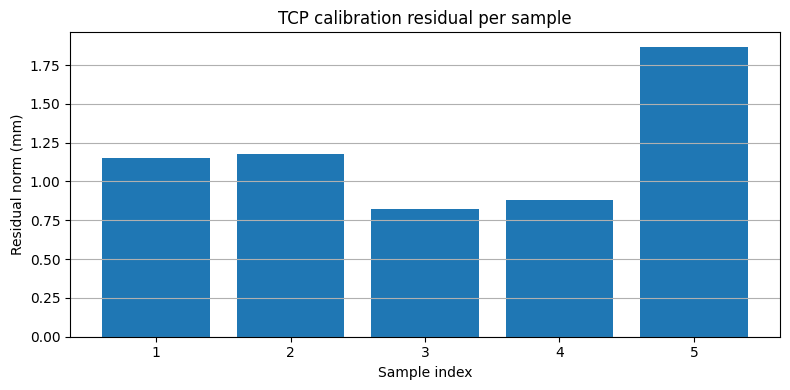

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(samples) + 1), residual_norms * 1000.0)
ax.set_xlabel('Sample index')
ax.set_ylabel('Residual norm (mm)')
ax.set_title('TCP calibration residual per sample')
ax.grid(True, axis='y')
plt.tight_layout()

**How it works:** `ax.bar(x, heights)` draws one bar per sample; `grid(True, axis='y')` only draws horizontal grid lines.
The bars are 0.8–1.9 mm: fairly even, with sample 5 the tallest.

---
## Task 13: Interpret the quality
Optional code: re-estimate with a subset of samples ("leave one out").

In [18]:
def calibrate(indices):
    """Estimate the flange-to-TCP transform from the samples with the given indices."""
    transforms = []
    for i in indices:
        a, x, r = samples[i]
        T_f = mycobot.fkine(np.radians(a), end=flange_link).A
        T_t = rpy_to_transform(np.array(x) / 1000.0, np.radians(r))
        transforms.append(np.linalg.inv(T_f) @ T_t)
    T_est = np.eye(4)
    T_est[:3, :3] = mean_rotation_svd([T[:3, :3] for T in transforms])
    T_est[:3, 3] = np.mean([T[:3, 3] for T in transforms], axis=0)
    return T_est

def residuals_mm(T_est, indices):
    out = []
    for i in indices:
        a, x, _ = samples[i]
        T_f = mycobot.fkine(np.radians(a), end=flange_link).A
        out.append(np.linalg.norm((T_f @ T_est)[:3, 3] - np.array(x) / 1000.0) * 1000.0)
    return np.array(out)

all_idx = list(range(len(samples)))
T_all = calibrate(all_idx)
print(f"{'dropped':>8s} {'offset xyz [mm]':>30s} {'mean res. of the rest':>22s} {'error on dropped sample':>24s}")
print(f"{'none':>8s} {str(np.round(T_all[:3, 3] * 1000, 2)):>30s} {residuals_mm(T_all, all_idx).mean():22.2f} {'-':>24s}")
for drop in all_idx:
    keep = [i for i in all_idx if i != drop]
    T_k = calibrate(keep)
    print(f"{drop + 1:8d} {str(np.round(T_k[:3, 3] * 1000, 2)):>30s} {residuals_mm(T_k, keep).mean():22.2f} "
          f"{residuals_mm(T_k, [drop])[0]:24.2f}")

 dropped                offset xyz [mm]  mean res. of the rest  error on dropped sample
    none            [-0.88 -1.72  0.17]                   1.18                        -
       1            [-1.03 -1.49  0.24]                   1.15                     1.44
       2            [-1.04 -1.48  0.25]                   1.14                     1.47
       3            [-0.77 -1.83  0.04]                   1.23                     1.03
       4            [-1.04 -1.81  0.05]                   1.25                     1.10
       5            [-0.52 -2.    0.29]                   0.89                     2.33


**How it works**
- `calibrate(indices)` repeats Tasks 6–9 for a subset of the samples; `residuals_mm` repeats Task 11. Wrapping a
  procedure in a function makes it reusable.
- `[i for i in all_idx if i != drop]` is a list comprehension with a condition: "all indices except `drop`".
- The table is a **leave-one-out** test: remove one sample, re-estimate, and see (a) how much the offset moves and
  (b) how badly the removed sample is predicted.

**Answers to the three questions**
1. *Are the residuals small relative to the repeatability (~0.5–1 mm)?* The mean residual is 1.2 mm and the worst 1.9 mm:
   a little above the quoted repeatability, but of the same order. That is reasonable for a low-cost arm and only five
   noisy manual measurements, and far below the 2.3 mm error without any calibration. Note the residual includes the
   noise of the *measurements* and the kinematic differences of the models, not only the robot's repeatability.
2. *Is any single sample an obvious outlier?* No. Sample 5 has the largest residual (1.87 mm) but it is not
   separated from the others (0.8–1.2 mm) by a clear gap.
3. *Would removing an outlier and re-estimating improve the calibration?* Removing sample 5 lowers the mean residual of
   the remaining four to 0.89 mm, but that is partly just having fewer points to fit (four points can always be
   fitted more closely than five). The decisive number is the last column: the re-estimated offset then predicts the
   removed sample **worse** (2.3 mm instead of 1.9 mm) and the offset moves by about 0.4 mm in x. So there is no
   good reason to throw it away; the better fix is to record **more** varied poses.

---
## Task 14: Compare with the launch-file values

In [19]:
# Known calibration result from the launch file
launch_tool_xyz = np.array([-0.0008809655, -0.0017207283, 0.0001719996])
launch_tool_rpy = np.array([4.91e-05, 2.52e-04, 5.37e-05])

# Your estimated translation
est_xyz = T_flange_tcp_est[:3, 3]

print('Launch ik_tool_xyz (mm):', launch_tool_xyz * 1000.0)
print('Your estimate (mm):     ', est_xyz * 1000.0)
print('Difference (mm):        ', (est_xyz - launch_tool_xyz) * 1000.0)

Launch ik_tool_xyz (mm): [-0.880965 -1.720728  0.172   ]
Your estimate (mm):      [-0.880965 -1.720728  0.172   ]
Difference (mm):         [0. 0. 0.]


**How it works / result**
- The difference prints as 0 (it is below $10^{-6}$ mm): the estimate **equals** the controller's calibration. The template
  expects "small differences from numerical precision or averaging"; here there are none worth mentioning, because
  the launch-file values were made from exactly these samples with exactly this algorithm (the launch file rounds to
  10 digits).
- So the calibrated tool offset is (−0.88, −1.72, +0.17) mm and a rotation of a few $10^{-4}$ rad: the "tool" is
  practically at the flange origin.
- The agreement is also a strong check on **your own code** and on the URDF model used here.

---
## Task 15 (optional): Base correction
`fk_tool_calib.py` also estimates a transform that compensates for a mismatch between the URDF base frame and the
frame in which the robot reported the measurements ("API base"). Per sample: ${}^{URDF}C_i = {}^BT_{F,i}\,({}^BT_{TCP,i})^{-1}$,
then average like the tool transform.

In [20]:
base_corrections = []
for i, (angles_deg, tcp_xyz_mm, tcp_rpy_deg) in enumerate(samples):
    T_f = mycobot.fkine(np.radians(angles_deg), end=flange_link).A
    T_t = rpy_to_transform(np.array(tcp_xyz_mm) / 1000.0, np.radians(tcp_rpy_deg))
    base_corr_i = T_f @ np.linalg.inv(T_t)          # per-sample base correction transform
    base_corrections.append(base_corr_i)

T_base_corr = np.eye(4)
T_base_corr[:3, :3] = mean_rotation_svd([T[:3, :3] for T in base_corrections])
T_base_corr[:3, 3] = np.mean([T[:3, 3] for T in base_corrections], axis=0)

def rot_to_rpy(rot):
    """
    Convert rotation matrix to [roll, pitch, yaw].
    Inverse of rpy_to_rot: R = Rz(yaw) @ Ry(pitch) @ Rx(roll).
    Matches rot_to_rpy in fk_tool_calib.py.
    """
    sy = -rot[2, 0]
    sy = max(-1.0, min(1.0, sy))
    pitch = math.asin(sy)
    cp = math.cos(pitch)
    if abs(cp) < 1e-6:
        roll = 0.0
        yaw = math.atan2(-rot[0, 1], rot[1, 1])
    else:
        roll = math.atan2(rot[2, 1] / cp, rot[2, 2] / cp)
        yaw = math.atan2(rot[1, 0] / cp, rot[0, 0] / cp)
    return [roll, pitch, yaw]

launch_base_xyz = np.array([0.0003774967, 0.0003297874, -0.0015915640])
launch_base_rpy = np.array([-4.76e-05, 2.29e-05, 1.87e-04])
print('estimated base xyz (mm):', T_base_corr[:3, 3] * 1000)
print('launch    ik_base_xyz (mm):', launch_base_xyz * 1000)
print('estimated base rpy (rad):', np.array(rot_to_rpy(T_base_corr[:3, :3])))
print('launch    ik_base_rpy (rad):', launch_base_rpy)

estimated base xyz (mm): [ 0.377497  0.329787 -1.591564]
launch    ik_base_xyz (mm): [ 0.377497  0.329787 -1.591564]
estimated base rpy (rad): [-0.000048  0.000023  0.000187]
launch    ik_base_rpy (rad): [-0.000048  0.000023  0.000187]


**How it works**
- $C_i = {}^BT_{F,i}\,({}^BT_{TCP,i})^{-1}$: "URDF's flange pose times the inverse of the API's pose" is the
  transform between the two base frames, **if** the tool offset is negligible (it is, ~2 mm). If the URDF base and
  the API base were identical, every $C_i$ would be the identity.
- The estimate: a translation of (0.38, 0.33, −1.59) mm and a rotation of 0.011°. So the API's base is about 1.6 mm
  lower than the URDF's base, and slightly rotated; the launch-file values `ik_base_xyz/rpy` match.
- **Tool vs base:** both corrections try to explain the same 2 mm of disagreement, so they are not independent.
  Effect on the mean residual (5 samples, position only):

| correction applied | mean residual |
|---|---|
| none | 2.26 mm |
| tool only (Task 9) | 1.18 mm |
| base only | 1.57 mm |
| both | 1.19 mm |

  With so few samples the tool alone does the job; the base correction adds nothing measurable (check with the next cell).

In [21]:
def mean_res_with(corr_base=None, tool=None):
    out = []
    for a, x, _ in samples:
        T_f = mycobot.fkine(np.radians(a), end=flange_link).A
        T_hat = T_f
        if corr_base is not None:
            T_hat = np.linalg.inv(corr_base) @ T_hat
        if tool is not None:
            T_hat = T_hat @ tool
        out.append(np.linalg.norm(T_hat[:3, 3] - np.array(x) / 1000.0) * 1000.0)
    return np.mean(out)

print('none      : %.2f mm' % mean_res_with())
print('tool only : %.2f mm' % mean_res_with(tool=T_flange_tcp_est))
print('base only : %.2f mm' % mean_res_with(corr_base=T_base_corr))
print('both      : %.2f mm' % mean_res_with(corr_base=T_base_corr, tool=T_flange_tcp_est))

none      : 2.26 mm
tool only : 1.18 mm
base only : 1.57 mm
both      : 1.19 mm


---
## Task 16: Extract `ik_tool_xyz` and `ik_tool_rpy`

In [22]:
ik_tool_xyz = T_flange_tcp_est[:3, 3]                    # calibrated tool translation (m)
ik_tool_rpy = rot_to_rpy(T_flange_tcp_est[:3, :3])       # calibrated tool rotation as [roll, pitch, yaw] (rad)

print('ik_tool_xyz:', ik_tool_xyz.tolist())
print('ik_tool_rpy:', ik_tool_rpy)
print('launch     :', launch_tool_rpy.tolist())

# round trip: the RPY must rebuild the same rotation matrix
print('round trip ok:', np.allclose(rpy_to_rot(ik_tool_rpy), T_flange_tcp_est[:3, :3]))

ik_tool_xyz: [-0.0008809654758489986, -0.0017207282750828778, 0.0001719996359936457]
ik_tool_rpy: [4.905950573384624e-05, 0.00025158630044371975, 5.37005534596307e-05]
launch     : [4.91e-05, 0.000252, 5.37e-05]
round trip ok: True


**How it works: the inverse of $R = R_zR_yR_x$**
With $c_y=\cos\text{yaw}$ etc., the matrix is
$$R=\begin{bmatrix} c_yc_p & c_ys_ps_r-s_yc_r & c_ys_pc_r+s_ys_r\\ s_yc_p & s_ys_ps_r+c_yc_r & s_ys_pc_r-c_ys_r\\ -s_p & c_ps_r & c_pc_r\end{bmatrix}.$$
- From the bottom-left entry: $R_{20} = -\sin(\text{pitch})$ ⇒ `pitch = asin(-R[2, 0])`. The value is clipped to
  [−1, 1] first because rounding can produce 1.0000000002, which `asin` rejects.
- Then $R_{21}/c_p = s_r$ and $R_{22}/c_p = c_r$ ⇒ `roll = atan2(R[2,1]/cp, R[2,2]/cp)`; and
  $R_{10}/c_p = s_y$, $R_{00}/c_p = c_y$ ⇒ `yaw = atan2(R[1,0]/cp, R[0,0]/cp)`. `atan2(y, x)` finds the correct quadrant.
- **Gimbal lock** (Lab 1): if $\cos(\text{pitch}) \approx 0$ the divisions are invalid and roll and yaw are not separable;
  the function sets roll = 0 and puts everything into yaw.
- `math.asin`, `math.atan2`, `math.cos` are the scalar functions of the standard library (fine for single numbers, no arrays).
- Result matches the launch parameters (4.9e-5, 2.5e-4, 5.4e-5 rad), all below 0.02°.
- These two lists are what you put into `mycobot_control.launch.py`: `'ik_tool_xyz': [...]`, `'ik_tool_rpy': [...]`.

---
## Task 17: How the controller uses the calibrated TCP
The controller works with **flange** poses inside its IK, but the user gives **TCP** targets. Since
${}^BT_{TCP} = {}^BT_F\,{}^FT_T$, the flange pose that puts the TCP on a target is
$$ {}^BT_F = {}^BT_{TCP,target}\;\big({}^FT_T\big)^{-1}, $$
which is the line `target_t = target_t @ _ik_tool_t_inv` (the inverse is computed once at start-up).

In [23]:
T_tool = T_flange_tcp_est
T_tool_inv = np.linalg.inv(T_tool)

# pick some flange pose, compute the corresponding TCP pose, then recover the flange pose from the TCP target
q_demo = np.radians([10, -30, -40, 20, 35, 5])
T_flange_true = mycobot.fkine(q_demo, end=flange_link).A
T_tcp_target = T_flange_true @ T_tool                   # where the TCP is for this flange pose
T_flange_needed = T_tcp_target @ T_tool_inv             # what IK must reach for that TCP target
print('recovered the flange pose:', np.allclose(T_flange_needed, T_flange_true))

# what a wrong (missing) calibration would do: IK reaches the target with the FLANGE instead of the TCP
err = np.linalg.norm((T_tcp_target @ np.eye(4))[:3, 3] - T_flange_true[:3, 3]) * 1000
print(f'without the tool offset the tool point would be {err:.2f} mm from where you asked')

recovered the flange pose: True
without the tool offset the tool point would be 1.94 mm from where you asked


**How it works**
- `T_tcp_target @ np.linalg.inv(T_tool)`: undo the last hop (flange → TCP). Matrix inverses reverse the order:
  $(AB)^{-1} = B^{-1}A^{-1}$.
- The demo shows the round trip is exact, and the size of the error you would get by ignoring the offset (about 2 mm for this
  data; for a real 68 mm suction nozzle it would be ~7 cm, see Lab 8).

---
## Task 18: Reflection
1. **Why does an incorrect TCP create systematic Cartesian error even when the joint angles are correct?**
   The joint angles fix the flange pose exactly (up to servo accuracy). The controller then assumes the working point is
   at ${}^FT_T$ from the flange. If that assumed offset is wrong by $\delta$, the real tool point is displaced from the
   commanded one by ${}^BR_F\,\delta$, and this displacement depends on the flange **orientation** but not on the
   position: the same wrong offset gives the same error in every repetition (systematic, not random), and it rotates
   with the tool. Joint accuracy cannot fix a geometry error.
2. **Why are several sufficiently different poses better than one or two?** One pose gives one equation per unknown
   component but with a fixed lever arm: noise and model errors in that pose go straight into the estimate. Different
   *orientations* make the offset appear in different directions of the base frame, so the components of the offset
   are separated from other errors (base, link lengths); different *positions* average out local kinematic errors.
   Averaging $n$ independent poses also reduces the noise by roughly $1/\sqrt n$, and the spread of the residuals
   shows how good the result is (with two poses you cannot tell).
3. **Why must the calibrated TCP be validated before use?** The estimation always returns *some* answer, even from bad data.
   The residuals (mean, max, RMS) show how well that answer explains the measurements; a large or uneven residual
   points to outliers, wrong units/frames, or a model mismatch. Validation with a practical test (approach the same
   point several times) catches errors that the numbers cannot. Using an unvalidated TCP would silently put a
   systematic error into all Cartesian motions (Lab 8's pick and place).

---
## Short questions from the PDF (preparation for the interview)
1. **What is a TCP and why is it usually not the flange origin?** The Tool Center Point is the effective working point
   of the tool (gripper centre, pen tip, suction nozzle tip). The flange is the robot's mechanical interface; the tool
   is mounted on it and extends beyond it, and its point of interest is somewhere on or at the end of the tool.
2. **Why is calibration necessary before Cartesian motions?** Cartesian targets refer to the TCP; without the correct
   flange-to-TCP transform the controller computes the joint angles for the flange, so the tool point misses the target by the offset.
3. **Flange frame vs TCP frame?** The flange frame belongs to the robot: fixed by its geometry, known from FK. The TCP
   frame belongs to the tool: depends on how and which tool is mounted; its origin and orientation can differ from the flange's.
4. **Which measurements are needed?** For several different poses: the joint angles (to compute the flange pose from
   FK) and the measured TCP position/orientation in the base frame (here from the robot API); plus the units and frame
   conventions.
5. **Basic idea of estimating one offset from several measurements?** Every pose gives an estimate
   $({}^BT_{F,i})^{-1}\,{}^BT_{TCP,i}$ of the same rigid offset; because of noise they differ, so combine them: average the
   translations, average the rotations with the SVD projection, i.e. a least-squares fit.
6. **How to validate; which error measures?** Recompute the TCP of every pose with the estimated offset and compare with the
   measurement: per-sample residual norm, mean, maximum (worst case, exposes outliers), RMS (overall size, punishes big
   errors); orientation error as well if used. Small and evenly distributed residuals mean a consistent estimate. Plus a
   practical repeat-approach test on the robot.
7. **Effect of an incorrect TCP?** Systematic positioning error (constant in the tool frame), wrong contact points, and
   repeated approaches missing the same way; with orientation changes the error changes direction, so precision drops
   for tools that rotate.
8. **Why several poses instead of one or two?** See reflection 2: better conditioning, less noise, and a way to
   estimate the quality.

---
## Summary
- ${}^FT_{T,i} = ({}^BT_{F,i})^{-1}\,{}^BT_{TCP,i}$; translation = mean, rotation = SVD projection $UV^T$ of the summed matrices.
- Validate by reprojecting: mean/max/RMS residual (here 1.2 / 1.9 / 1.2 mm; 2.3 mm without the tool offset).
- Result equals the launch-file calibration: `ik_tool_xyz` ≈ (−0.88, −1.72, 0.17) mm, `ik_tool_rpy` ≈ 0.
- The controller uses $T_{target}\,T_{tool}^{-1}$ to turn TCP targets into flange targets.